# House Price Prediction

**Internship Project | CodTech IT Solutions**

### Objective
Predict the price of a house based on features like area, number of bedrooms, bathrooms, stories, and amenities (air conditioning, parking, furnishing status, etc.) using **Linear Regression**.

### Dataset
`Housing.csv` — 545 houses with the following columns:
- `price` — target variable (in Rupees)
- `area`, `bedrooms`, `bathrooms`, `stories`, `parking` — numeric features
- `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea` — yes/no features
- `furnishingstatus` — furnished / semi-furnished / unfurnished

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Load the Dataset

In [2]:
df = pd.read_csv("Housing.csv")
print("Shape:", df.shape)
df.head()

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,9421000,15857,6,3,2,yes,yes,yes,no,no,2,no,furnished
1,9396000,16482,4,3,1,yes,no,no,no,yes,3,yes,furnished
2,9166000,15569,6,2,3,yes,no,yes,no,no,0,yes,furnished
3,8914000,16073,6,1,3,yes,no,yes,no,yes,2,no,semi-furnished
4,8889000,14858,5,2,4,no,no,yes,no,yes,0,no,furnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,5.870536e+06,9033.456881,3.464220,1.803670,1.968807,1.141284
std,1.631835e+06,4234.644327,1.153282,0.874467,0.879160,0.966461
min,2.273000e+06,1714.000000,1.000000,1.000000,1.000000,0.000000
25%,4.492000e+06,5413.000000,3.000000,1.000000,1.000000,0.000000
50%,5.886000e+06,8920.000000,3.000000,2.000000,2.000000,1.000000
75%,7.136000e+06,12746.000000,4.000000,2.000000,2.000000,2.000000
max,9.421000e+06,16482.000000,6.000000,4.000000,4.000000,3.000000


## 2. Exploratory Data Analysis (EDA)

A quick look at how price relates to a few important features.

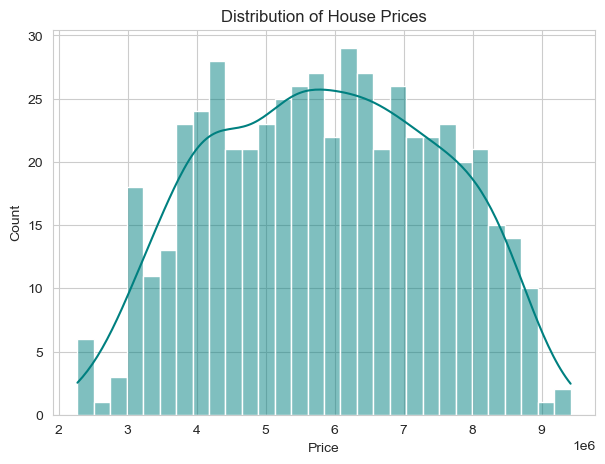

In [5]:
plt.figure(figsize=(7,5))
sns.histplot(df['price'], bins=30, kde=True, color='teal')
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.show()

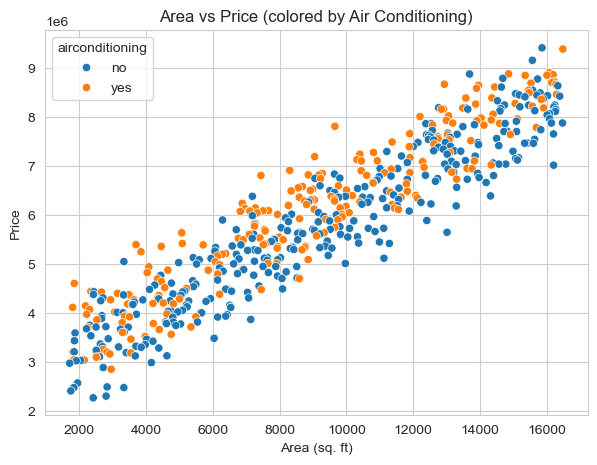

In [6]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='area', y='price', data=df, hue='airconditioning')
plt.title("Area vs Price (colored by Air Conditioning)")
plt.xlabel("Area (sq. ft)")
plt.ylabel("Price")
plt.show()

C:\Users\Apurba\AppData\Local\Temp\ipykernel_8560\3315412852.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bedrooms', y='price', data=df, palette='Set2')


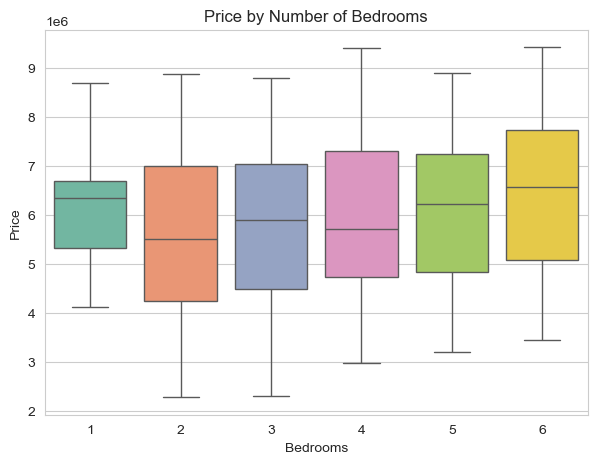

In [7]:
plt.figure(figsize=(7,5))
sns.boxplot(x='bedrooms', y='price', data=df, palette='Set2')
plt.title("Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

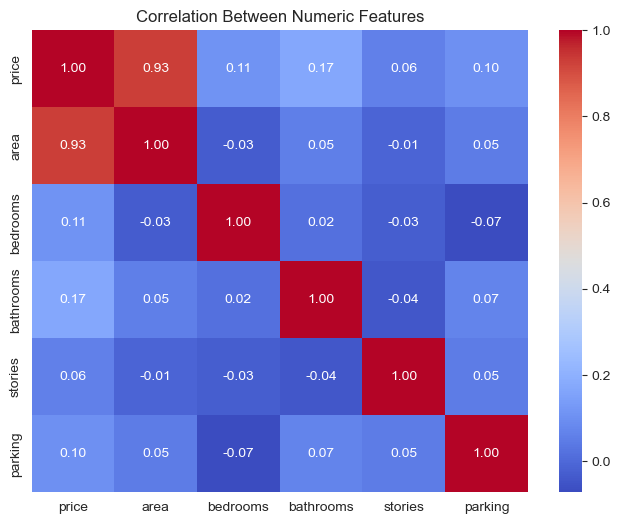

In [8]:
plt.figure(figsize=(8,6))
numeric_df = df[['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Between Numeric Features")
plt.show()

## 3. Data Preprocessing

The yes/no columns and furnishing status need to be converted into numbers before they can be used in Linear Regression.

In [9]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

data = df.copy()
for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})

data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,9421000,15857,6,3,2,1,1,1,0,0,2,0,furnished
1,9396000,16482,4,3,1,1,0,0,0,1,3,1,furnished
2,9166000,15569,6,2,3,1,0,1,0,0,0,1,furnished
3,8914000,16073,6,1,3,1,0,1,0,1,2,0,semi-furnished
4,8889000,14858,5,2,4,0,0,1,0,1,0,0,furnished


In [10]:
# One-hot encode furnishing status (3 categories -> dummy columns)
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,9421000,15857,6,3,2,1,1,1,0,0,2,0,False,False
1,9396000,16482,4,3,1,1,0,0,0,1,3,1,False,False
2,9166000,15569,6,2,3,1,0,1,0,0,0,1,False,False
3,8914000,16073,6,1,3,1,0,1,0,1,2,0,True,False
4,8889000,14858,5,2,4,0,0,1,0,1,0,0,False,False


In [11]:
X = data.drop(columns=['price'])
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 436
Testing samples: 109


## 4. Training the Model

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 5. Model Evaluation

In [13]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: Rs. {mae:,.0f}")
print(f"Root Mean Squared Error: Rs. {rmse:,.0f}")
print(f"R2 Score: {r2:.3f}")

Mean Absolute Error: Rs. 313,345
Root Mean Squared Error: Rs. 387,445
R2 Score: 0.957


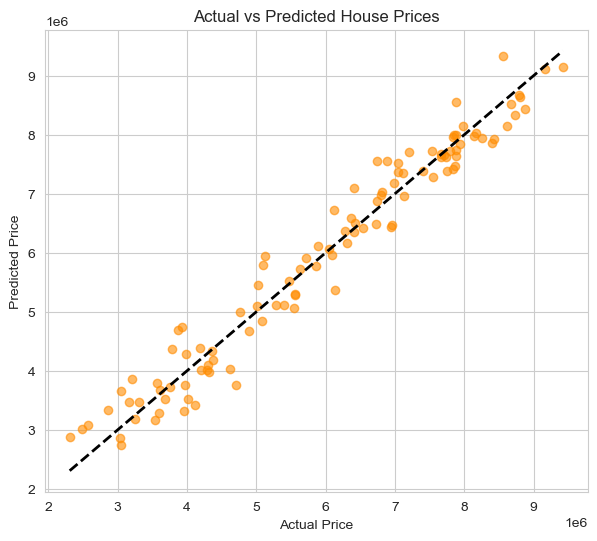

In [14]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## 6. Feature Importance (Coefficients)

C:\Users\Apurba\AppData\Local\Temp\ipykernel_8560\3611023216.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients.values, y=coefficients.index, palette='viridis')


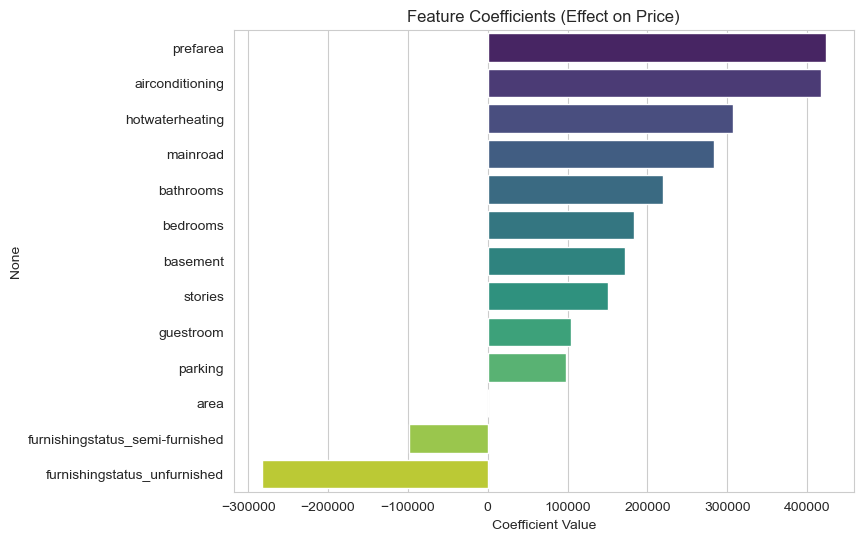

prefarea                           423138.786158
airconditioning                    417341.513021
hotwaterheating                    306908.923683
mainroad                           283729.401747
bathrooms                          219407.521762
bedrooms                           183573.826548
basement                           172523.172229
stories                            150745.175552
guestroom                          104761.049612
parking                             98082.758710
area                                  349.271462
furnishingstatus_semi-furnished    -98412.197472
furnishingstatus_unfurnished      -282658.378434
dtype: float64

In [15]:
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=coefficients.values, y=coefficients.index, palette='viridis')
plt.title("Feature Coefficients (Effect on Price)")
plt.xlabel("Coefficient Value")
plt.show()

coefficients

## 7. Insights

- **Area has the strongest relationship with price** — larger houses consistently cost more.
- **Air conditioning and preferred area (prefarea) add a noticeable premium** to the price.
- **Number of bathrooms and stories** also push price up, though less than area.
- Furnishing status has a smaller effect compared to structural features like area and bedrooms.

## 8. Interactive Prediction Demo

The function below takes details of a new house as input and predicts its price using the trained model.

In [16]:
def predict_price():
    print("Enter house details to predict price:\n")

    area = float(input("Area (in sq. ft): "))
    bedrooms = int(input("Number of Bedrooms: "))
    bathrooms = int(input("Number of Bathrooms: "))
    stories = int(input("Number of Stories: "))
    mainroad = input("On main road? (yes/no): ").strip().lower()
    guestroom = input("Has guest room? (yes/no): ").strip().lower()
    basement = input("Has basement? (yes/no): ").strip().lower()
    hotwaterheating = input("Has hot water heating? (yes/no): ").strip().lower()
    airconditioning = input("Has air conditioning? (yes/no): ").strip().lower()
    parking = int(input("Number of parking spaces: "))
    prefarea = input("In a preferred area? (yes/no): ").strip().lower()
    furnishingstatus = input("Furnishing status (furnished/semi-furnished/unfurnished): ").strip().lower()

    input_dict = {
        'area': area,
        'bedrooms': bedrooms,
        'bathrooms': bathrooms,
        'stories': stories,
        'mainroad': 1 if mainroad == 'yes' else 0,
        'guestroom': 1 if guestroom == 'yes' else 0,
        'basement': 1 if basement == 'yes' else 0,
        'hotwaterheating': 1 if hotwaterheating == 'yes' else 0,
        'airconditioning': 1 if airconditioning == 'yes' else 0,
        'parking': parking,
        'prefarea': 1 if prefarea == 'yes' else 0,
        'furnishingstatus_semi-furnished': 1 if furnishingstatus == 'semi-furnished' else 0,
        'furnishingstatus_unfurnished': 1 if furnishingstatus == 'unfurnished' else 0,
    }

    input_df = pd.DataFrame([input_dict])
    input_df = input_df[X.columns]  # match training column order

    predicted_price = model.predict(input_df)[0]

    print("\n--- Prediction Result ---")
    print(f"Estimated Price: Rs. {predicted_price:,.0f}")

# Call the function to try it
predict_price()

Enter house details to predict price:


--- Prediction Result ---
Estimated Price: Rs. 5,676,391


**Example inputs to try:**
- 6000 sq. ft, 3 bedrooms, 2 bathrooms, 2 stories, mainroad yes, no guestroom, basement yes, no hot water heating, airconditioning yes, 2 parking, prefarea yes, furnished
- 3000 sq. ft, 2 bedrooms, 1 bathroom, 1 story, mainroad yes, no guestroom, no basement, no hot water heating, no airconditioning, 0 parking, prefarea no, unfurnished